## ChatGPT Word Count

In [21]:
import pandas as pd
import spacy
from collections import Counter

# Load processed data
df = pd.read_csv("df_desc_with_chatgpt_counts.csv")
df = df[df["details_JobPositionPosting_JobPositionInformation_Purpose"].notna()]

# Load SpaCy model and lemmatize GPT-style words (same as original script)
nlp = spacy.load("da_core_news_lg")

chatgpt_words_raw = [
    "problemfrit", "testamente", "billedtæppe", "fremvisning", "understregningstegn",
    "afgørende", "riget", "omhyggelig", "revolutionere", "fascinere", "gobelin",
    "omfattende", "levende", "vital", "dynamisk", "desuden", "analyserer",
    "udnyt", "facilitere", "løftestang", "afgørende"
]

# Lemmatize target words
chatgpt_words = set()
for word in chatgpt_words_raw:
    doc = nlp(word.lower())
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    chatgpt_words.update(lemmas)

# Count individual lemma matches across the corpus
counter = Counter()

for text in df["details_JobPositionPosting_JobPositionInformation_Purpose"].str.lower():
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    matched = [lemma for lemma in lemmas if lemma in chatgpt_words]
    counter.update(matched)

# Display top 10
top10 = counter.most_common(10)
top10_df = pd.DataFrame(top10, columns=["word", "count"])
display(top10_df)

# Optional: Save to CSV
top10_df.to_csv("top10_chatgpt_words_posthoc.csv", index=False)


,word,count
0,dynamisk,3720
1,desuden,3659
2,afgørende,1711
3,rig,1432
4,omhyggelig,689
5,facilitere,447
6,levende,439
7,omfattende,307
8,analysere,188
9,fremvisning,112


In [32]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("df_desc_with_chatgpt_counts.csv")

# Display the first 5 rows
print(df.head())

  summary_PostingCreated  \
0    2025-01-07 00:00:00   
1    2022-05-06 00:00:00   
2    2022-05-04 00:00:00   
3    2022-04-25 00:00:00   
4    2025-02-03 07:58:17   

  details_JobPositionPosting_JobPositionInformation_Purpose  \
0  Elsker du biler, og brænder du for kvalitetsar...          
1  BDO er en af Danmarks største rådgivnings- og ...          
2  Institution Sdr. Omme, Sønder Omme Fængsel søg...          
3  Brænder du for at arbejde med ældre, er du fag...          
4  Om jobbet: Børnehuset Vandet består af to børn...          

   chatgpt_word_count  total_word_count  chatgpt_word_ratio      group  
0                 2.0             364.0            5.494505  2024/2025  
1                 0.0             547.0            0.000000       2022  
2                 1.0             619.0            1.615509       2022  
3                 0.0             502.0            0.000000       2022  
4                 0.0             989.0            0.000000  2024/2025  


In [18]:
import pandas as pd

# Load data
df = pd.read_csv("df_desc_with_chatgpt_counts.csv")
#df = df.dropna(subset=["group", "chatgpt_word_ratio", "chatgpt_word_count"])

print(df.groupby("group")["chatgpt_word_ratio"].describe())


             count      mean       std  min  25%  50%       75%       max
group                                                                    
2022       14617.0  1.147741  2.027841  0.0  0.0  0.0  1.972387  40.00000
2024/2025  10051.0  1.299181  2.039164  0.0  0.0  0.0  2.151695  29.70297


In [13]:

nonzero_df = df[df["chatgpt_word_ratio"] > 0]


print(nonzero_df.groupby("group")["chatgpt_word_ratio"].describe())


            count      mean       std       min       25%       50%       75%  \
group                                                                           
2022       5069.0  3.309634  2.168602  0.576369  1.886792  2.710027  4.000000   
2024/2025  4133.0  3.159464  2.057859  0.670241  1.801802  2.597403  4.016064   

                max  
group                
2022       40.00000  
2024/2025  29.70297  


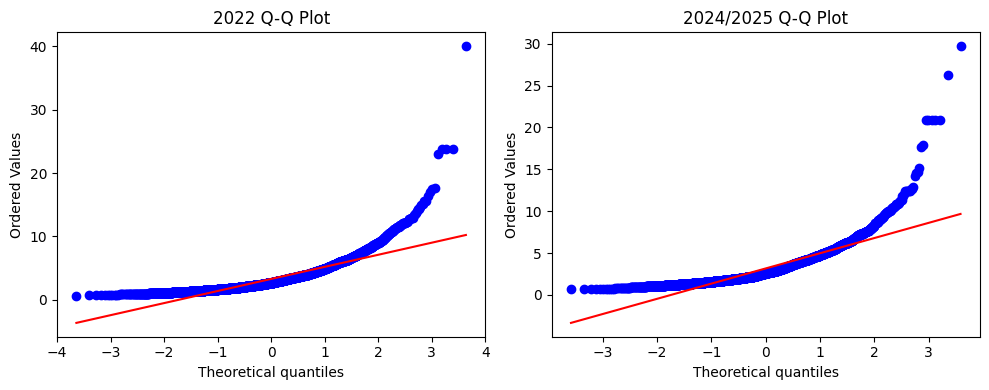

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_86544/3721777744.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = nonzero_df[df["group"] == group]["chatgpt_word_ratio"]
/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_86544/3721777744.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = nonzero_df[df["group"] == group]["chatgpt_word_ratio"]


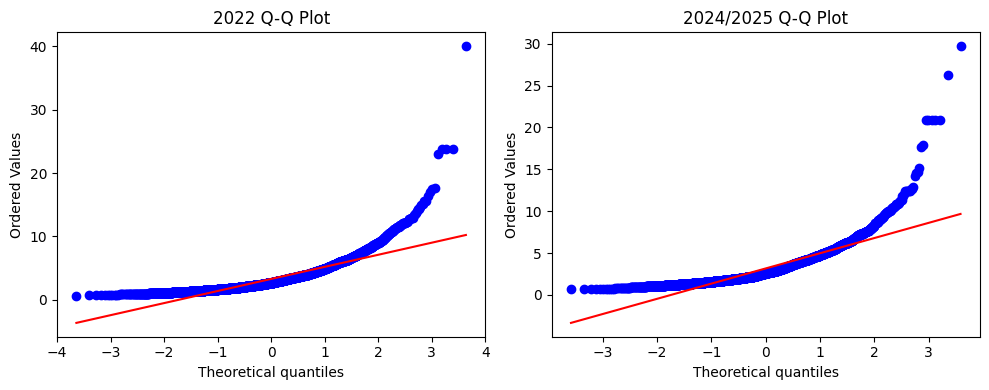

In [14]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = nonzero_df[nonzero_df["group"] == group]["chatgpt_word_ratio"]
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"{group} Q-Q Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = nonzero_df[df["group"] == group]["chatgpt_word_ratio"]
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"{group} Q-Q Plot")
plt.tight_layout()
plt.show()


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_86544/2342934374.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = nonzero_df[df["group"] == group]["chatgpt_word_ratio"]
/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_86544/2342934374.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = nonzero_df[df["group"] == group]["chatgpt_word_ratio"]


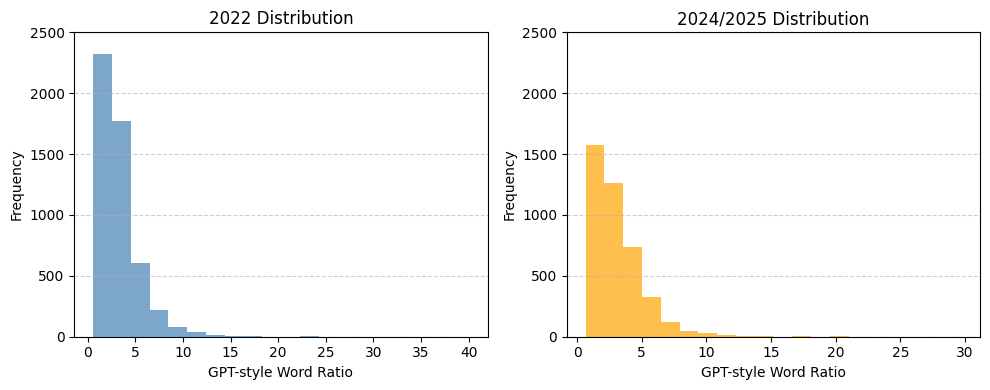

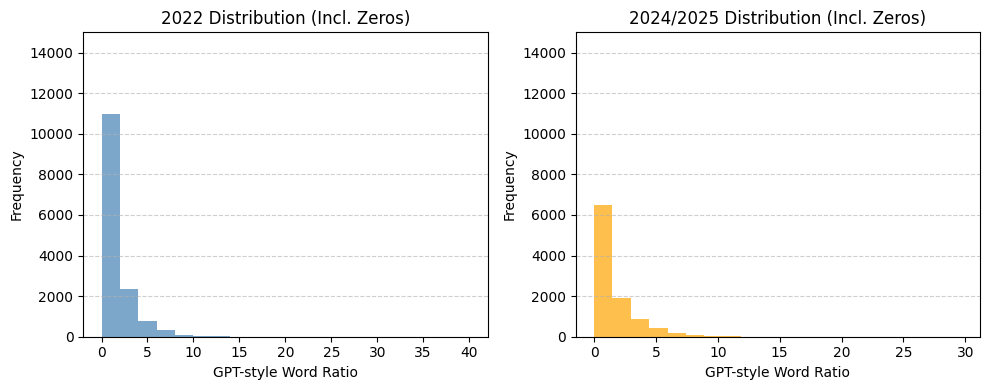

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = nonzero_df[df["group"] == group]["chatgpt_word_ratio"]
    plt.hist(data, bins=20, color="steelblue" if group == "2022" else "orange", alpha=0.7)
    plt.title(f"{group} Distribution")
    plt.xlabel("GPT-style Word Ratio")
    plt.ylabel("Frequency")
    plt.xlim(0, 40)
    plt.ylim(0, 2500)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i, group in enumerate(["2022", "2024/2025"], 1):
    plt.subplot(1, 2, i)
    data = df[(df["group"] == group)]["chatgpt_word_ratio"]
    plt.hist(data, bins=20, color="steelblue" if group == "2022" else "orange", alpha=0.7)
    plt.title(f"{group} Distribution (Incl. Zeros)")
    plt.xlabel("GPT-style Word Ratio")
    plt.ylabel("Frequency")
    plt.xlim(0, 40)
    plt.ylim(0,15000)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




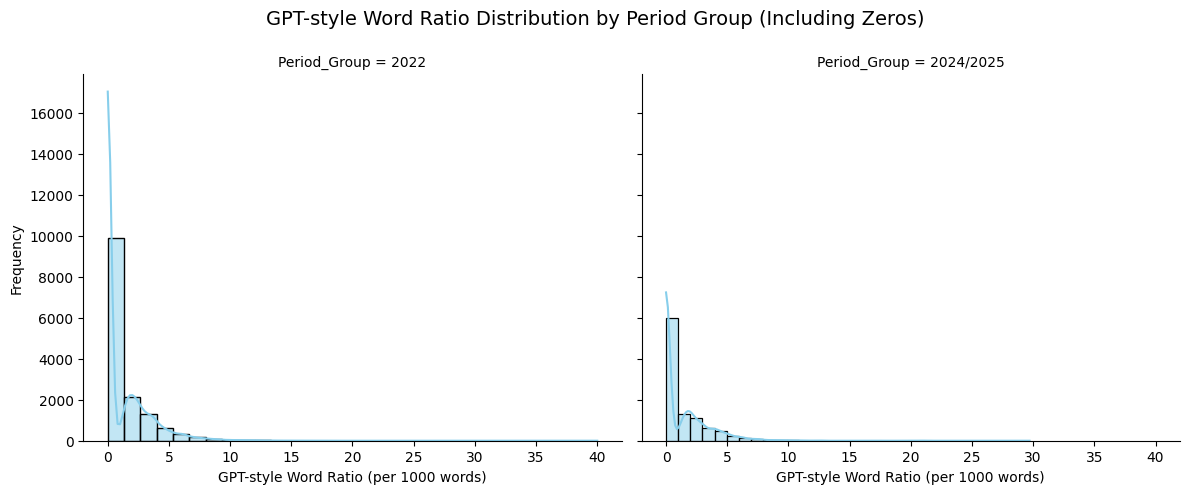

Plot saved to 'plot_outputs/chatgpt_ratio_distribution_incl_zeros.png'


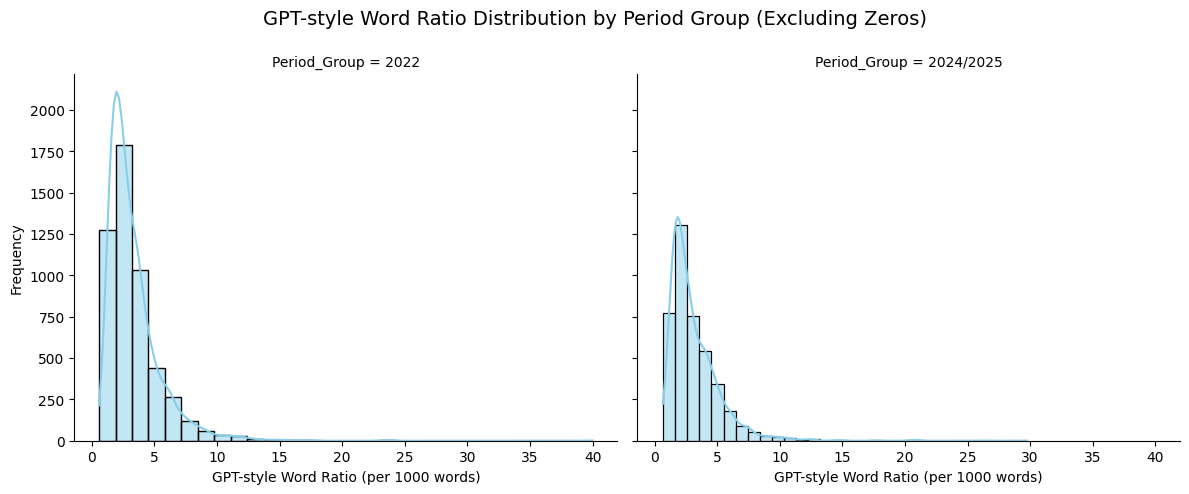

Plot saved to 'plot_outputs/chatgpt_ratio_distribution_excl_zeros.png'


In [31]:
# Faceted histogram INCLUDING zeros (full dataset)
g = sns.FacetGrid(
    df_gpt_grouped,  # already filtered for Period_Group in ['2022', '2024/2025']
    col="Period_Group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "chatgpt_word_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("GPT-style Word Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("GPT-style Word Ratio Distribution by Period Group (Including Zeros)", fontsize=14)

# Save plot
output_path_incl = os.path.join(output_plots_dir, "chatgpt_ratio_distribution_incl_zeros.png")
plt.savefig(output_path_incl, dpi=300)
plt.show()

print(f"Plot saved to '{output_path_incl}'")

# Filter to only non-zero GPT-style word ratio rows
df_gpt_nonzero = df_gpt_grouped[df_gpt_grouped["chatgpt_word_ratio"] > 0]

# Faceted histogram EXCLUDING zeros
g = sns.FacetGrid(
    df_gpt_nonzero,
    col="Period_Group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "chatgpt_word_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("GPT-style Word Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("GPT-style Word Ratio Distribution by Period Group (Excluding Zeros)", fontsize=14)

# Save plot
output_path_excl = os.path.join(output_plots_dir, "chatgpt_ratio_distribution_excl_zeros.png")
plt.savefig(output_path_excl, dpi=300)
plt.show()

print(f"Plot saved to '{output_path_excl}'")


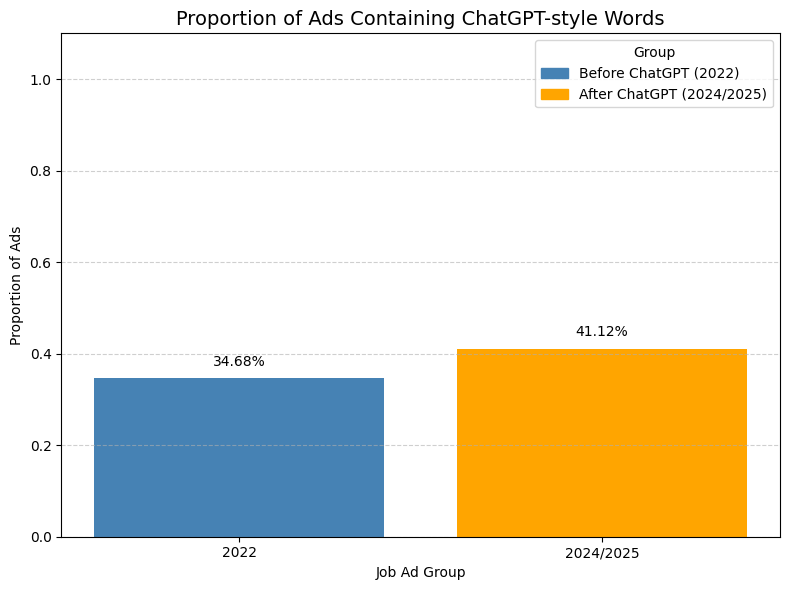

Plot saved to: plot_outputs/proportion_gpt_ads_grouped.png


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_86544/3456659435.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


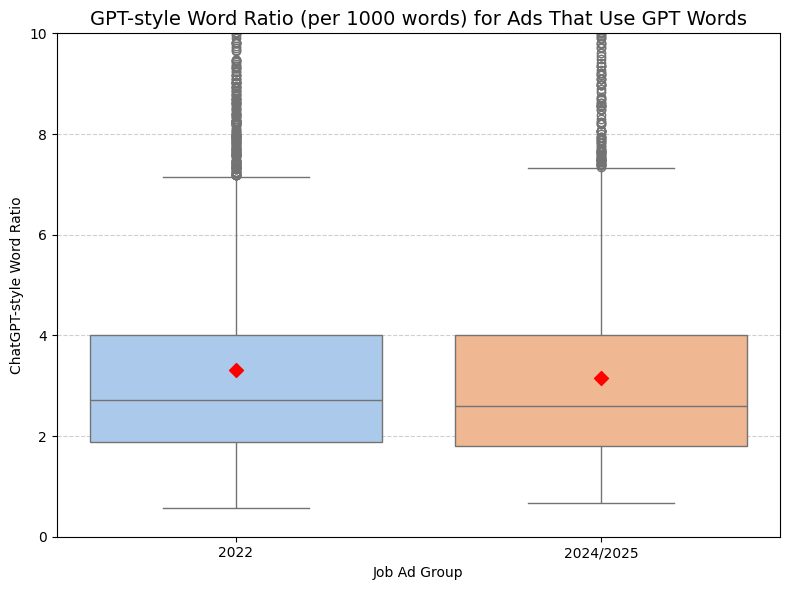

Boxplot saved to: plot_outputs/gpt_word_ratio_boxplot_by_group.png
Levene’s test: W = 1.640, p = 0.2003
Proportion Z-test: z = -10.279, p = 0.0000
Welch’s t-test: t = -3.399, p = 0.0007
Mann-Whitney U test: U = 9966105.5, p = 0.0001
Cohen's d: -0.071


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, levene
from statsmodels.stats.proportion import proportions_ztest
import os
from matplotlib.patches import Patch


# Load data
df = pd.read_csv("df_desc_with_chatgpt_counts.csv")
df = df.dropna(subset=["group", "chatgpt_word_ratio", "chatgpt_word_count"])

# --- Bar Plot: Proportion of ads using GPT-style words ---
# Create output directory for consistency
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# --- Bar Plot: Proportion of ads using GPT-style words ---
df["has_gpt_word"] = df["chatgpt_word_count"] > 0
prop_df = df.groupby("group")["has_gpt_word"].mean().reset_index()

# Define colors based on group
bar_colors = ["steelblue" if g == "2022" else "orange" for g in prop_df["group"]]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(prop_df["group"], prop_df["has_gpt_word"], color=bar_colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2%}", ha='center', va='bottom', fontsize=10)

# Labels and formatting
ax.set_title("Proportion of Ads Containing ChatGPT-style Words", fontsize=14)
ax.set_xlabel("Job Ad Group")
ax.set_ylabel("Proportion of Ads")
ax.set_ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Legend
legend_handles = [
    Patch(color="steelblue", label="Before ChatGPT (2022)"),
    Patch(color="orange", label="After ChatGPT (2024/2025)")
]
ax.legend(handles=legend_handles, title="Group")

# Save and show plot
output_path = os.path.join(output_plot_dir, "proportion_gpt_ads_grouped.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to: {output_path}")

# --- Boxplot: Intensity of GPT-style words (only non-zero ads) ---

# Filter non-zero ratio entries
nonzero_df = df[df["chatgpt_word_ratio"] > 0]

# Plot setup
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=nonzero_df,
    x='group',
    y='chatgpt_word_ratio',
    order=["2022", "2024/2025"],
    palette='pastel',
    whis=1.5
)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = nonzero_df.groupby("group")["chatgpt_word_ratio"].mean()
for i, group in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[group], color='red', zorder=10, marker='D', s=50)

# Labels and formatting
plt.title("GPT-style Word Ratio (per 1000 words) for Ads That Use GPT Words", fontsize=14)
plt.xlabel("Job Ad Group")
plt.ylabel("ChatGPT-style Word Ratio")
plt.ylim(0, 10)  # Adjust as needed
plt.tight_layout()

# Save and show
output_path = os.path.join("plot_outputs", "gpt_word_ratio_boxplot_by_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")

# --- Prepare groups ---
group_2022 = df[df["group"] == "2022"]
group_recent = df[df["group"] == "2024/2025"]

# For Welch's and Mann-Whitney: only compare intensity where ratio > 0
intensity_2022 = group_2022[group_2022["chatgpt_word_ratio"] > 0]["chatgpt_word_ratio"]
intensity_recent = group_recent[group_recent["chatgpt_word_ratio"] > 0]["chatgpt_word_ratio"]

# --- Levene’s Test (equality of variance) ---
lev_stat, lev_p = levene(intensity_2022, intensity_recent)
print(f"Levene’s test: W = {lev_stat:.3f}, p = {lev_p:.4f}")

# --- Proportion Z-Test ---
successes = [
    (group_2022["chatgpt_word_count"] > 0).sum(),
    (group_recent["chatgpt_word_count"] > 0).sum()
]
nobs = [len(group_2022), len(group_recent)]

z_stat, z_p = proportions_ztest(successes, nobs)
print(f"Proportion Z-test: z = {z_stat:.3f}, p = {z_p:.4f}")

# --- Welch’s T-test ---
t_stat, t_p = ttest_ind(intensity_recent, intensity_2022, equal_var=False)
print(f"Welch’s t-test: t = {t_stat:.3f}, p = {t_p:.4f}")

# --- Mann-Whitney U Test ---
u_stat, u_p = mannwhitneyu(intensity_recent, intensity_2022, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat}, p = {u_p:.4f}")

# --- Cohen's d ---
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled_sd = np.sqrt(((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2))
    return diff / pooled_sd

d = cohens_d(intensity_recent, intensity_2022)
print(f"Cohen's d: {d:.3f}")


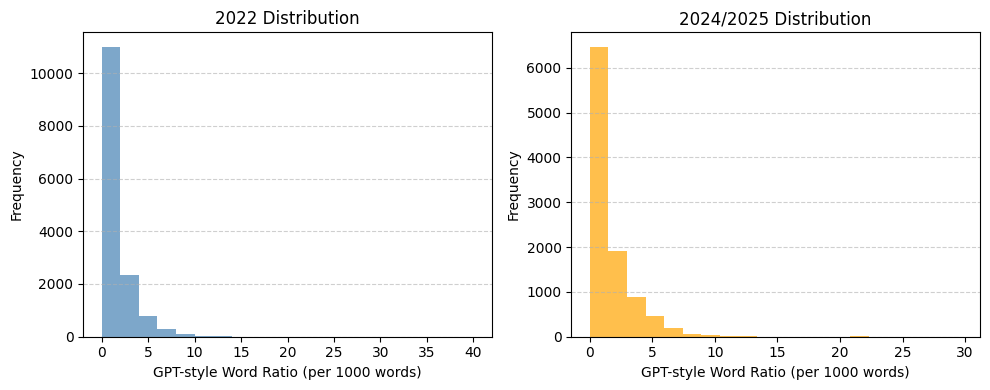

In [22]:
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)

# Ensure group is a column with valid values
df_gpt_ratio = df[df["group"].isin(["2022", "2024/2025"])].copy()

# Plot using Seaborn's FacetGrid for consistency
g = sns.FacetGrid(
    df_gpt_ratio,
    col="group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "chatgpt_word_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("GPT-style Word Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("GPT-style Word Ratio Distribution by Period Group", fontsize=14)

# Save the figure
output_path = os.path.join(output_dir, "2chatgpt_ratio_distribution_by_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")



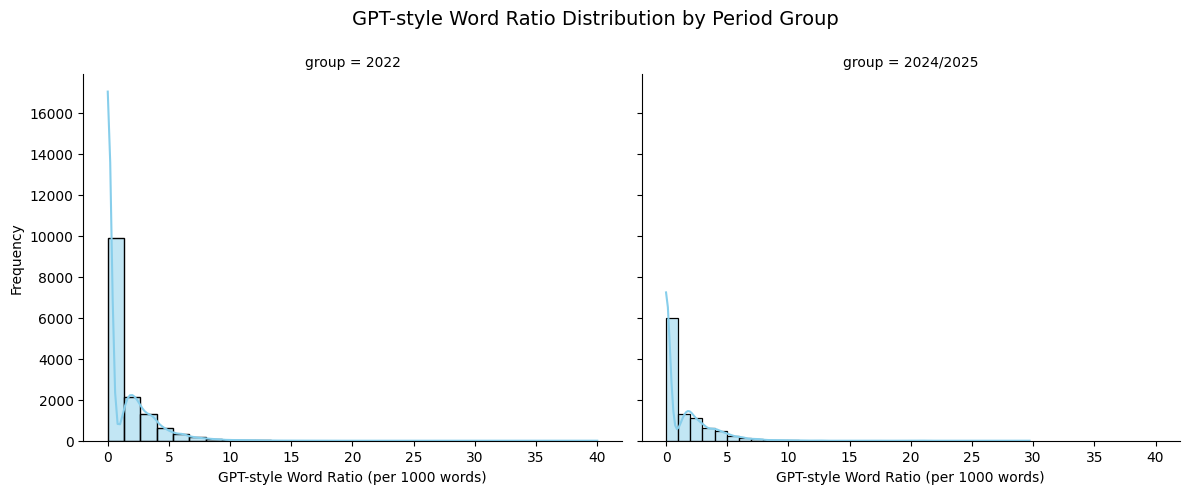

Plot saved to 'plot_outputs/chatgpt_ratio_distribution_by_group.png'


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)

# Ensure group is a column with valid values
df_gpt_ratio = df[df["group"].isin(["2022", "2024/2025"])].copy()

# Plot using Seaborn's FacetGrid for consistency
g = sns.FacetGrid(
    df_gpt_ratio,
    col="group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "chatgpt_word_ratio", bins=30, kde=True, color="skyblue")
g.set_axis_labels("GPT-style Word Ratio (per 1000 words)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("GPT-style Word Ratio Distribution by Period Group", fontsize=14)

# Save the figure
output_path = os.path.join(output_dir, "chatgpt_ratio_distribution_by_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")


## Gender Word Count


📊 Comparing `fem_ratio` (2022 vs. 2024/2025)
  Levene’s test:     W = 2.584, p = 0.1079
  Welch’s t-test:    t = -3.641, p = 0.0003
  Mann-Whitney U:    U = 70015054, p = 0.0000
  Cohen’s d:         d = -0.047


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_60825/241736661.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df[var].notna()], x="group", y=var, palette="Set2")


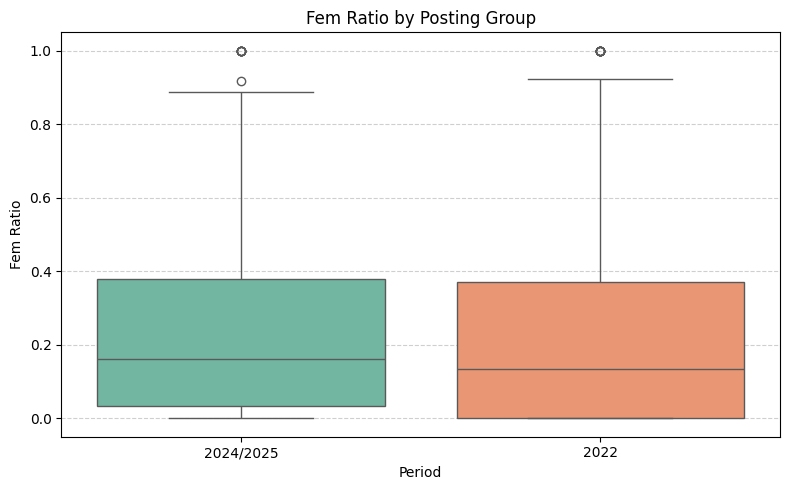


📊 Comparing `masc_ratio` (2022 vs. 2024/2025)
  Levene’s test:     W = 5.353, p = 0.0207
  Welch’s t-test:    t = 2.985, p = 0.0028
  Mann-Whitney U:    U = 75692202, p = 0.0000
  Cohen’s d:         d = 0.039


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_60825/241736661.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df[var].notna()], x="group", y=var, palette="Set2")


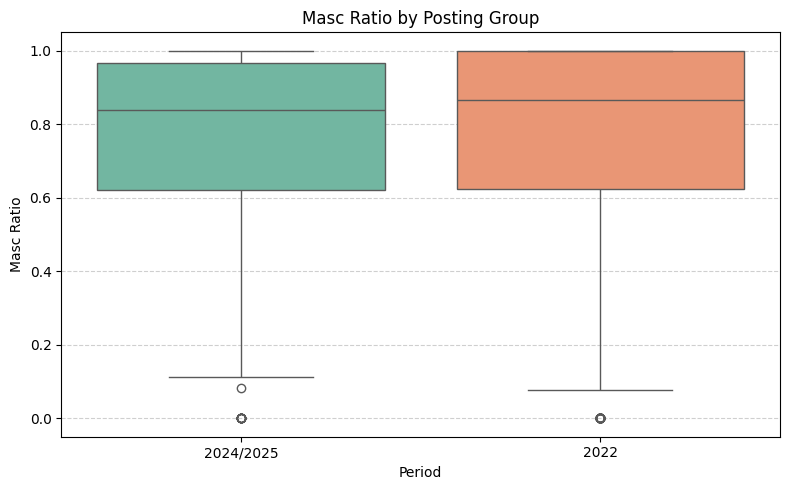


📊 Comparing `gendered_ratio` (2022 vs. 2024/2025)
  Levene’s test:     W = 0.246, p = 0.6197
  Welch’s t-test:    t = -6.963, p = 0.0000
  Mann-Whitney U:    U = 69631710, p = 0.0000
  Cohen’s d:         d = -0.090


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_60825/241736661.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df[var].notna()], x="group", y=var, palette="Set2")


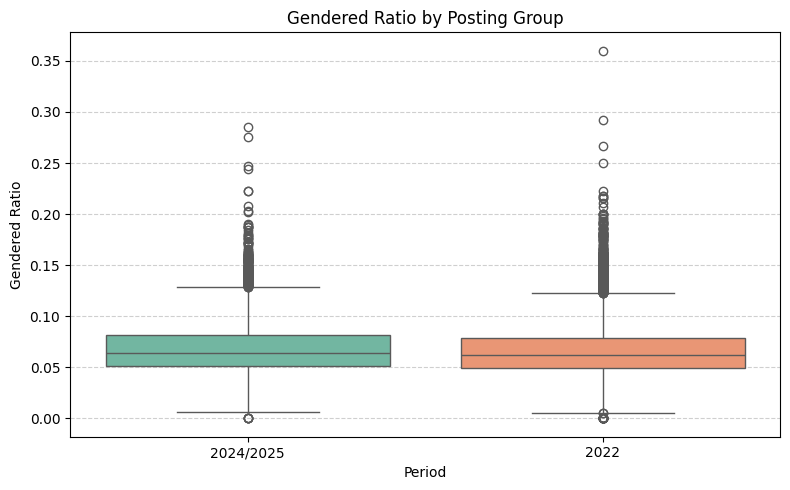


📊 Z-test for proportion of `has_feminine`:
  Proportion 2022:        0.733
  Proportion 2024/2025:   0.797
  z = -11.489, p = 0.0000

📊 Z-test for proportion of `has_masculine`:
  Proportion 2022:        0.997
  Proportion 2024/2025:   0.999
  z = -2.685, p = 0.0072


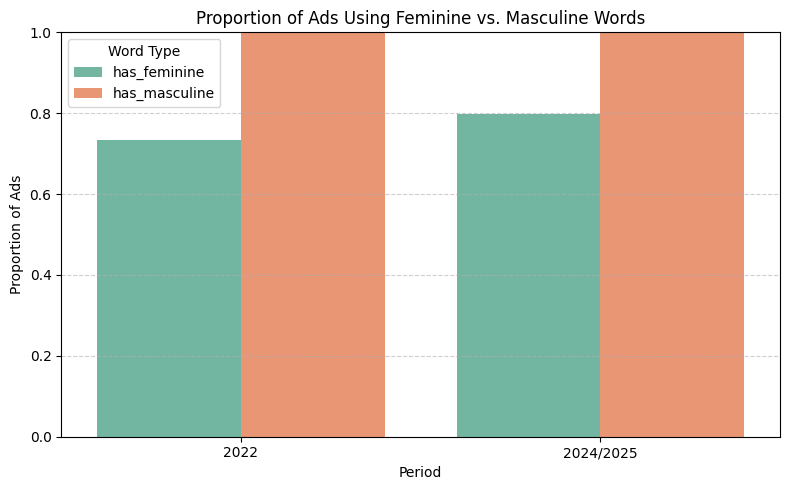

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, levene
from statsmodels.stats.proportion import proportions_ztest

# --- Load the enriched gender word count dataset ---
df = pd.read_csv("df_cgw_genderword_counts_with_groups.csv")

# --- Filter groups for comparison ---
group_2022 = df[df["group"] == "2022"]
group_recent = df[df["group"] == "2024/2025"]

# --- Comparison helper for continuous variables ---
def compare_metric(var):
    x = group_2022[var].dropna()
    y = group_recent[var].dropna()

    # Levene's test (variance equality)
    lev_stat, lev_p = levene(x, y)

    # Welch’s t-test
    t_stat, t_p = ttest_ind(x, y, equal_var=False)

    # Mann-Whitney U test
    u_stat, u_p = mannwhitneyu(x, y, alternative="two-sided")

    # Cohen's d
    def cohens_d(a, b):
        pooled_sd = np.sqrt(((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2))
        return (np.mean(a) - np.mean(b)) / pooled_sd

    d = cohens_d(x, y)

    print(f"\n📊 Comparing `{var}` (2022 vs. 2024/2025)")
    print(f"  Levene’s test:     W = {lev_stat:.3f}, p = {lev_p:.4f}")
    print(f"  Welch’s t-test:    t = {t_stat:.3f}, p = {t_p:.4f}")
    print(f"  Mann-Whitney U:    U = {u_stat:.0f}, p = {u_p:.4f}")
    print(f"  Cohen’s d:         d = {d:.3f}")

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df[df[var].notna()], x="group", y=var, palette="Set2")
    plt.title(f"{var.replace('_', ' ').title()} by Posting Group")
    plt.xlabel("Period")
    plt.ylabel(var.replace('_', ' ').title())
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Run comparisons and plots for continuous metrics ---
compare_metric("fem_ratio")
compare_metric("masc_ratio")
compare_metric("gendered_ratio")

# --- Comparison helper for proportions ---
def compare_proportions(var):
    count = [
        group_2022[var].sum(),
        group_recent[var].sum()
    ]
    nobs = [len(group_2022), len(group_recent)]

    z_stat, p_val = proportions_ztest(count, nobs)

    print(f"\n📊 Z-test for proportion of `{var}`:")
    print(f"  Proportion 2022:        {count[0] / nobs[0]:.3f}")
    print(f"  Proportion 2024/2025:   {count[1] / nobs[1]:.3f}")
    print(f"  z = {z_stat:.3f}, p = {p_val:.4f}")

# --- Run proportion tests ---
compare_proportions("has_feminine")
compare_proportions("has_masculine")

# --- Plot bar chart for has_feminine and has_masculine ---
prop_df = df.groupby("group")[["has_feminine", "has_masculine"]].mean().reset_index()
prop_df_melted = prop_df.melt(id_vars="group", var_name="Word Type", value_name="Proportion")

plt.figure(figsize=(8, 5))
sns.barplot(data=prop_df_melted, x="group", y="Proportion", hue="Word Type", palette="Set2")
plt.title("Proportion of Ads Using Feminine vs. Masculine Words")
plt.ylabel("Proportion of Ads")
plt.xlabel("Period")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Gendered Titles Over Time

📊 Chi-squared test (feminine vs masculine titles only):
  Chi² = 1.400, p = 0.2367

Contingency table:
 gender_category  feminine  masculine
Period_Group                        
2022                  849         22
2024_2025             536         21

Expected counts:
 gender_category    feminine  masculine
Period_Group                          
2022             844.772409  26.227591
2024_2025        540.227591  16.772409


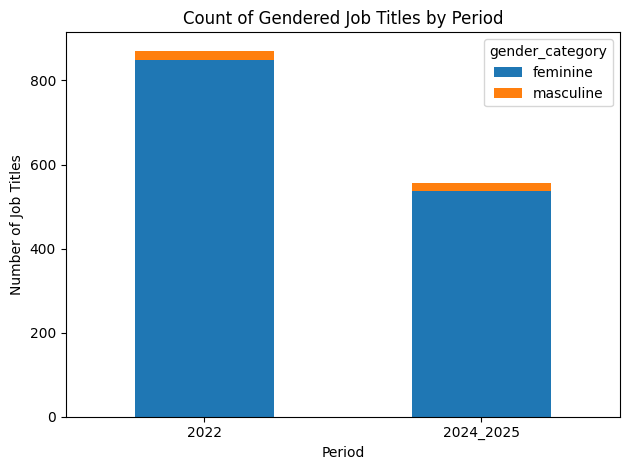

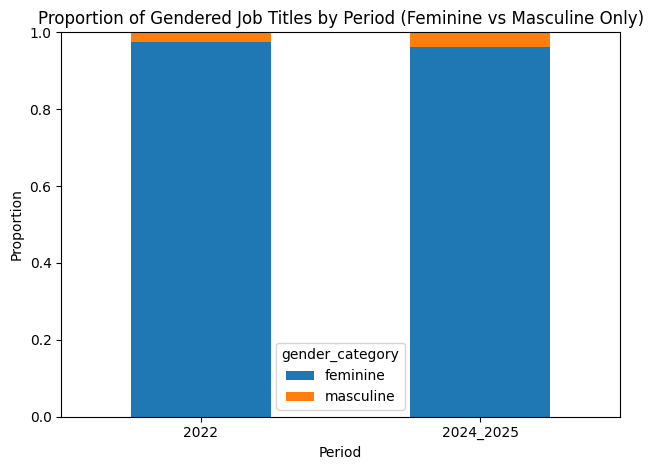


📊 Z-test for proportion of feminine job titles over all titles:
  2022: 849/14617 = 5.808%
  2024/2025: 536/10051 = 5.333%
  z = 1.594, p = 0.1109


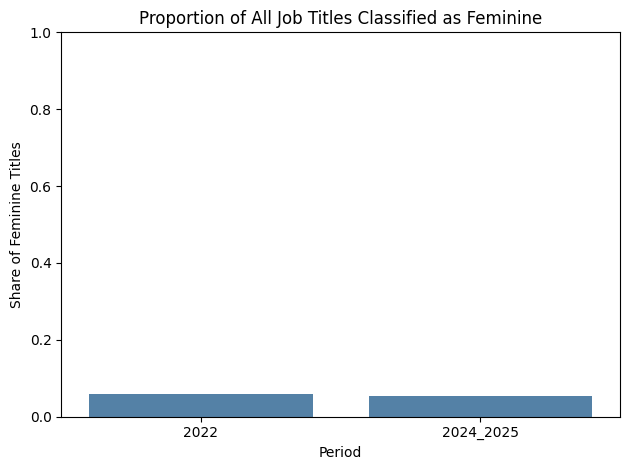

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import re

# --- Load and prepare data ---
df = pd.read_csv("df_desc_filt.csv", low_memory=False)
df['summary_PostingCreated'] = pd.to_datetime(df['summary_PostingCreated'], errors='coerce')
df['Posting_Year'] = df['summary_PostingCreated'].dt.year
df['Period_Group'] = df['Posting_Year'].apply(lambda y: '2022' if y == 2022 else ('2024_2025' if y in [2024, 2025] else None))
df = df[df['Period_Group'].notnull()].copy()

# --- Gender classification ---
feminine_suffixes = ["dame", "frue", "inde", "trice", "øse", "ske", "kone", "ert", "mor", "jomfru"]
masculine_suffixes = ["mand", "svend"]

def classify_gender(title):
    title = str(title).strip().lower()
    words = re.findall(r'\b\w+\b', title)
    has_feminine = any(word.endswith(suffix) for word in words for suffix in feminine_suffixes)
    has_masculine = any(word.endswith(suffix) for word in words for suffix in masculine_suffixes)
    if has_feminine and has_masculine:
        return 'both'
    elif has_feminine:
        return 'feminine'
    elif has_masculine:
        return 'masculine'
    else:
        return 'none'

df['gender_category'] = df['summary_Occupation'].apply(classify_gender)

# --- Filter only gendered titles for chi-squared test ---
df_gendered = df[df['gender_category'].isin(['feminine', 'masculine'])].copy()

# --- Chi-squared test on 2x2 ---
contingency = pd.crosstab(df_gendered['Period_Group'], df_gendered['gender_category'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("📊 Chi-squared test (feminine vs masculine titles only):")
print(f"  Chi² = {chi2:.3f}, p = {p:.4f}")
print("\nContingency table:\n", contingency)
print("\nExpected counts:\n", pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

# --- Plot 1: Absolute counts of gendered titles ---
contingency.plot(kind='bar', stacked=True)
plt.title("Count of Gendered Job Titles by Period")
plt.xlabel("Period")
plt.ylabel("Number of Job Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Plot 2: Normalized proportions of gendered titles ---
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)
contingency_norm.plot(kind='bar', stacked=True)
plt.title("Proportion of Gendered Job Titles by Period (Feminine vs Masculine Only)")
plt.xlabel("Period")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Z-test: feminine titles as % of all job ads ---
fem_counts = df['gender_category'].eq("feminine")
successes = [
    fem_counts[df['Period_Group'] == "2022"].sum(),
    fem_counts[df['Period_Group'] == "2024_2025"].sum()
]
nobs = [
    (df['Period_Group'] == "2022").sum(),
    (df['Period_Group'] == "2024_2025").sum()
]

z_stat, z_p = proportions_ztest(successes, nobs)
print(f"\n📊 Z-test for proportion of feminine job titles over all titles:")
print(f"  2022: {successes[0]}/{nobs[0]} = {successes[0]/nobs[0]:.3%}")
print(f"  2024/2025: {successes[1]}/{nobs[1]} = {successes[1]/nobs[1]:.3%}")
print(f"  z = {z_stat:.3f}, p = {z_p:.4f}")

# --- Plot 3: % of all job ads labeled 'feminine' ---
fem_share_df = df.groupby('Period_Group')['gender_category'].apply(
    lambda col: (col == 'feminine').mean()
).reset_index(name='Feminine Share')

sns.barplot(data=fem_share_df, x='Period_Group', y='Feminine Share', color='steelblue')
plt.title("Proportion of All Job Titles Classified as Feminine")
plt.ylabel("Share of Feminine Titles")
plt.xlabel("Period")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
